# Clase 10 — Analizando el catálogo de Netflix

En este ejercicio asumirás el rol de un **Data Analyst** dentro de Netflix. El equipo de negocio quiere entender mejor cómo está distribuido el catálogo de la plataforma para tomar decisiones sobre futuras inversiones en contenido.

Para ello deberás utilizar las herramientas aprendidas en esta clase:

- `groupby()`
- funciones de agregación
- `agg()`
- `pivot_table()`
- `unstack()`
- gráficos con Pandas y Matplotlib

> No utilices bucles (`for`) para resolver los ejercicios.


In [2]:
import pandas as pd

df = pd.read_csv("/workspaces/data-analysis-course/modulo-3-transformacion/clase-10/ventas_retail.csv")

df.groupby("ciudad")["monto"].sum()

ciudad
Buenos Aires    8855199
Córdoba         7198111
Mendoza         7706414
Rosario         7938539
Tucumán         7221605
Name: monto, dtype: int64

In [3]:
df.groupby(["ciudad", "categoria"])["monto"].sum()

ciudad        categoria  
Buenos Aires  Alimentos      1876997
              Deportes       1372041
              Electrónica    1951331
              Hogar          1607118
              Ropa           2047712
Córdoba       Alimentos      1787767
              Deportes       1778075
              Electrónica    1286509
              Hogar          1292147
              Ropa           1053613
Mendoza       Alimentos       891215
              Deportes       1718730
              Electrónica    1472067
              Hogar          1533021
              Ropa           2091381
Rosario       Alimentos      1715244
              Deportes       1676528
              Electrónica    1526021
              Hogar          1783981
              Ropa           1236765
Tucumán       Alimentos      2595971
              Deportes       1047502
              Electrónica    1445364
              Hogar          1324889
              Ropa            807879
Name: monto, dtype: int64

In [13]:
df.groupby("vendedor")["monto"].agg(["sum", "mean", "count", "max"])

,sum,mean,count,max
vendedor,,,,
Ana Torres,5592010,79885.857143,70,149832
Carlos Vera,5114603,75214.750000,68,145272
Clara Díaz,5051539,77715.984615,65,148273
Lucía Paz,4423650,77607.894737,57,145180
Luis Gómez,5188342,76299.147059,68,149701
María López,4380650,70655.645161,62,146398
Pedro Ruiz,4105135,78944.903846,52,146706
Sofía Herrera,5063939,87309.293103,58,149539


In [24]:
df.groupby("vendedor").agg(
    total_ventas = ("monto", sum),
    ticket_promedio = ("monto", "mean"),
    unidades_vendidas = ("monto", "count"),
    maxima_venta = ("monto", max)
)

,total_ventas,ticket_promedio,unidades_vendidas,maxima_venta
vendedor,,,,
Ana Torres,5592010,79885.857143,70,149832
Carlos Vera,5114603,75214.750000,68,145272
Clara Díaz,5051539,77715.984615,65,148273
Lucía Paz,4423650,77607.894737,57,145180
Luis Gómez,5188342,76299.147059,68,149701
María López,4380650,70655.645161,62,146398
Pedro Ruiz,4105135,78944.903846,52,146706
Sofía Herrera,5063939,87309.293103,58,149539


In [20]:
df.groupby("ciudad").agg(
    total_ventas = ("monto", "sum"),
    unidades_totales = ("unidades", "sum"),
    descuento_max = ("descuento", "max")
)

,total_ventas,unidades_totales,descuento_max
ciudad,,,
Buenos Aires,8855199,1089,0.2
Córdoba,7198111,931,0.2
Mendoza,7706414,1175,0.2
Rosario,7938539,946,0.2
Tucumán,7221605,880,0.2


In [29]:
resultado = df.groupby("ciudad")["monto"].sum()
print(type(resultado.index))
print(resultado.index)

resultado_plano = resultado.reset_index()
print(resultado_plano)

<class 'pandas.Index'>
Index(['Buenos Aires', 'Córdoba', 'Mendoza', 'Rosario', 'Tucumán'], dtype='str', name='ciudad')
         ciudad    monto
0  Buenos Aires  8855199
1       Córdoba  7198111
2       Mendoza  7706414
3       Rosario  7938539
4       Tucumán  7221605


In [32]:
tabla = df.pivot_table(
    values  = "monto",
    index   = "ciudad",
    columns = "categoria",
    aggfunc = "sum",
)
tabla

categoria,Alimentos,Deportes,Electrónica,Hogar,Ropa
ciudad,,,,,
Buenos Aires,1876997,1372041,1951331,1607118,2047712
Córdoba,1787767,1778075,1286509,1292147,1053613
Mendoza,891215,1718730,1472067,1533021,2091381
Rosario,1715244,1676528,1526021,1783981,1236765
Tucumán,2595971,1047502,1445364,1324889,807879


In [13]:
tabla_multiple = df.pivot_table(
    values  = "monto",
    index   = "ciudad",
    columns = "trimestre",
    aggfunc = ["sum", "mean"],
)

tabla_multiple["mean"] = tabla_multiple["mean"].round(1)

tabla_multiple

sum                                mean                    \
trimestre          Q1       Q2       Q3       Q4       Q1       Q2       Q3   
ciudad                                                                        
Buenos Aires  2556390  2735824  1607655  1955330  75187.9  88252.4  76555.0   
Córdoba       1632413  1596225  1932245  2037228  77734.0  69401.1  80510.2   
Mendoza       2500488  1617051  1907793  1681082  73543.8  64682.0  70659.0   
Rosario       1957784  2212611  2461971  1306173  81574.3  96200.5  82065.7   
Tucumán       1536296  2079097  1103564  2502648  73157.0  77003.6  91963.7   

                       
trimestre          Q4  
ciudad                 
Buenos Aires  85014.3  
Córdoba       75452.9  
Mendoza       64657.0  
Rosario       93298.1  
Tucumán       75837.8

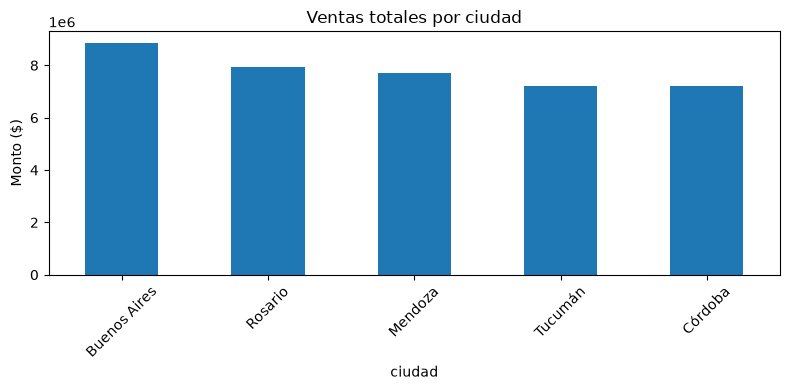

In [16]:
import matplotlib.pyplot as plt

# Ventas totales por ciudad — gráfico de barras
totales_ciudad = df.groupby("ciudad")["monto"].sum().sort_values(ascending=False)

totales_ciudad.plot(kind="bar", figsize=(8, 4), title="Ventas totales por ciudad")
plt.ylabel("Monto ($)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

=== Ciudad con más ventas ===
ciudad
Buenos Aires    8855199
Rosario         7938539
Mendoza         7706414
Tucumán         7221605
Córdoba         7198111
Name: monto, dtype: int64

Ganadora: Buenos Aires ($8,855,199)

=== Ingresos por categoría y trimestre ===
trimestre         Q1       Q2       Q3       Q4
categoria                                      
Alimentos    2018617  2420102  1798483  2629992
Deportes     2331622  1667151  2095008  1499095
Electrónica  2180347  2155875  1656060  1689010
Hogar        1420609  2045656  1688955  2385936
Ropa         2232176  1952024  1774722  1278428

=== Ticket promedio por vendedor ===
vendedor
Sofía Herrera    87309.0
Ana Torres       79886.0
Pedro Ruiz       78945.0
Clara Díaz       77716.0
Lucía Paz        77608.0
Luis Gómez       76299.0
Carlos Vera      75215.0
María López      70656.0
Name: monto, dtype: float64

Mejor ticket promedio: Sofía Herrera ($87,309)


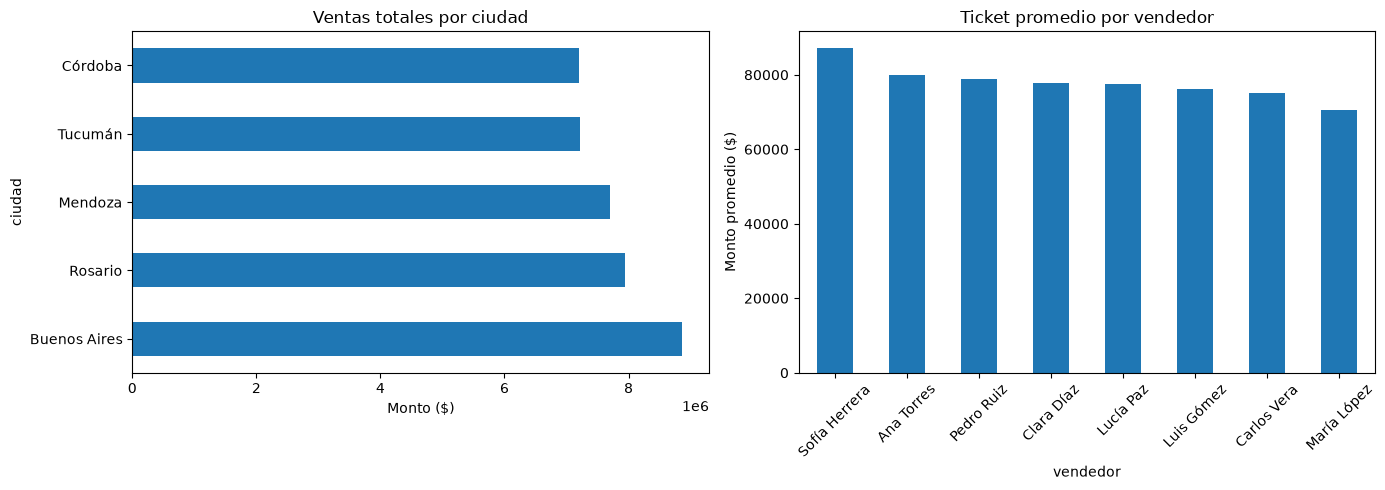

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/workspaces/data-analysis-course/modulo-3-transformacion/clase-10/ventas_retail.csv")

# ¿Qué ciudad vende más?
print("=== Ciudad con más ventas ===")
por_ciudad = df.groupby("ciudad")["monto"].sum().sort_values(ascending=False)
print(por_ciudad)
print(f"\nGanadora: {por_ciudad.index[0]} (${por_ciudad.iloc[0]:,.0f})")

# ¿Qué categoría genera más ingresos por trimestre?
print("\n=== Ingresos por categoría y trimestre ===")
tabla_trim = df.pivot_table(
    values    = "monto",
    index     = "categoria",
    columns   = "trimestre",
    aggfunc   = "sum",
    fill_value= 0,
)
print(tabla_trim)

# ¿Qué vendedor tiene el ticket promedio más alto?
print("\n=== Ticket promedio por vendedor ===")
ticket = df.groupby("vendedor")["monto"].mean().sort_values(ascending=False)
print(ticket.round(0))
print(f"\nMejor ticket promedio: {ticket.index[0]} (${ticket.iloc[0]:,.0f})")

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

por_ciudad.plot(kind="barh", ax=axes[0], title="Ventas totales por ciudad")
axes[0].set_xlabel("Monto ($)")

ticket.plot(kind="bar", ax=axes[1], title="Ticket promedio por vendedor")
axes[1].set_ylabel("Monto promedio ($)")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

## Parte 1: Exploración del dataset

Antes de comenzar el análisis responde:

1. Carga el dataset.
2. Muestra las primeras filas.
3. ¿Cuántas filas y columnas posee?
4. ¿Qué tipo de dato tiene cada columna?
5. ¿Existen valores nulos?
6. ¿Qué columnas presentan mayor cantidad de valores faltantes?

In [40]:
ds = pd.read_csv("netflix_data.csv") #carga dataset
ds.head() #muestro las 5 primeras filas
print(ds.shape) #cantidad de filas y columnas que posee
ds.dtypes #tipo de dato de cada columna
ds.isnull().sum() #valores nulos
ds.isnull().mean() * 100 #porcentaje de valores faltantes por columna


(8807, 12)


show_id          0.000000
type             0.000000
title            0.000000
director        29.908028
cast             9.367549
country          9.435676
date_added       0.113546
release_year     0.000000
rating           0.045418
duration         0.034064
listed_in        0.000000
description      0.000000
dtype: float64

## Parte 2: Agrupaciones

### Ejercicio 1 - ¿Cuántos títulos existen por país?

Ordena el resultado de mayor a menor.


In [54]:
ds_limpio = ds.dropna(subset=["country"]).copy()
ds_limpio["country"] = ds_limpio["country"].str.split(",")
ds_limpio = ds_limpio.explode("country")
ds_limpio["country"] = ds_limpio["country"].str.strip()



In [55]:

titulos_pais = ds_limpio.groupby("country")["show_id"].count().sort_values(ascending=False)
print(titulos_pais)

country
United States     3690
India             1046
United Kingdom     806
Canada             445
France             393
                  ... 
Slovakia             1
Samoa                1
Sri Lanka            1
Uganda               1
Vatican City         1
Name: show_id, Length: 123, dtype: int64


### Ejercicio 2 - ¿Cuántas películas y cuántas series tiene Netflix?

In [ ]:
# tu código acá

### Ejercicio 3 - ¿Cuántos títulos fueron lanzados cada año?

Ordena el resultado cronológicamente.


In [ ]:
# tu código acá

### Ejercicio 4 - ¿Cuál es la clasificación por edades más frecuente?

Por ejemplo:

- TV-MA
- TV-14
- PG
- R

In [ ]:
# tu código acá

### Ejercicio 5 - Obtén para cada tipo de contenido (Movie y TV Show):

- cantidad de títulos
- año promedio de lanzamiento
- año más reciente
- año más antiguo

> Utiliza **agg()**.

In [ ]:
# tu código acá

## Parte 3: Agrupaciones múltiples

### Ejercicio 6 - Obtén la cantidad de títulos para cada combinación.

Agrupa por:

- país
- tipo de contenido

In [ ]:
# tu código acá

### Ejercicio 7 - Convierte el resultado anterior en una tabla donde:

- las filas sean los países
- las columnas sean Movie y TV Show

> Utiliza **unstack()**.

In [ ]:
# tu código acá

## Parte 4: Tablas dinámicas

### Ejercicio 8 - Construye una tabla dinámica donde:

- filas → país
- columnas → tipo de contenido
- valores → cantidad de títulos

In [ ]:
# tu código acá

### Ejercicio 9 - Construye otra tabla dinámica donde:

- filas → clasificación por edades
- columnas → tipo de contenido
- valores → cantidad de títulos

In [ ]:
# tu código acá

### Ejercicio 10 - Modifica la tabla dinámica para que los valores faltantes aparezcan como **0**.

In [ ]:
# tu código acá

## Parte 5: Visualización

### Ejercicio 11 - Genera un gráfico de barras con el **Top 10 países con mayor cantidad de títulos**.

El gráfico debe incluir:

- título
- tamaño de figura
- etiquetas rotadas
- eje Y con nombre


In [ ]:
# tu código acá

### Ejercicio 12 - Genera un gráfico de barras mostrando la cantidad de:

- Movies
- TV Shows

In [ ]:
# tu código acá

### Ejercicio 13 - Utilizando la tabla dinámica, crea un gráfico de barras agrupadas que compare películas y series por país.


In [ ]:
# tu código acá

## Parte 6: Análisis

Redacta al menos **cinco insights** basados en el análisis realizado. Algunas preguntas que puedes responder son:

- ¿Qué país domina el catálogo?
- ¿Netflix posee más películas o más series?
- ¿Qué clasificación por edades es la más utilizada?
- ¿Existen países donde predominen las series?
- ¿Qué tendencia observas respecto al año de lanzamiento de los contenidos?

Justifica cada respuesta utilizando los datos obtenidos.

In [ ]:
# tu código acá

## Desafío

Netflix desea aumentar su presencia en Latinoamérica. Analiza únicamente los siguientes países:

- Argentina
- Brasil
- Chile
- Colombia
- México
- Perú

Responde:

1. ¿Cuál aporta mayor cantidad de contenido?
2. ¿Predominan las películas o las series?
3. ¿Qué clasificación por edades es la más común?
4. Genera un gráfico comparativo.
5. Escribe una breve recomendación para el director regional de Netflix basada en tus resultados.


In [ ]:
# tu código acá